In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os


In [3]:
model_name = 'LR'

dataset_combo = "CL_VA"

save_tables = 0

In [4]:
base_dataset_name = dataset_combo.split("_")[0]
derived_dataset_name =  dataset_combo.split("_")[1]

match base_dataset_name:
        case 'CL':
            base_dataset = "Cleveland"
            len_base = 303

        case 'HG':
            base_dataset = "Hungary"
            len_base = 294

        case 'SW':
            base_dataset = "Switzerland"
            len_base = 123
        
        case 'VA':
            base_dataset = "Long Beach VA"
            len_base = 200

        case _:
            raise SystemExit("Valid name of base dataset is not provided")
     
match derived_dataset_name:
        case 'CL':
            derived_dataset = "Cleveland"
            len_derived = 303

        case 'HG':
            derived_dataset = "Hungary"
            len_derived = 294

        case 'SW':
            derived_dataset = "Switzerland"
            len_derived = 123
            
        case 'VA':
            derived_dataset = "Long Beach VA"
            len_derived = 200

        case _:
            raise SystemExit("Valid name of derived dataset is not provided")

In [7]:
# !ls ../../Final_Results/HD/CL_HG/


ls: ../../Final_Results/HD/CL_HG/: No such file or directory


In [5]:
path = './Final_Results/HD/'+dataset_combo+"/"+model_name+"/"

In [6]:
dfs = {100:{}, 90:{}, 80:{}, 70:{}, 60:{}, 50:{}}

isExist = os.path.exists(path)

if isExist:
    for file_name in os.listdir(path):
        if file_name.endswith(".csv"):
            with open(path+file_name, 'r') as file:
                df = pd.read_csv(file)
                num_models = int(file_name.split('_')[0])
                agreement_rate = float(file_name.split('_')[-3])
                dfs[num_models][agreement_rate] = df
            
    derived_label_match_results = {100:{}, 90:{}, 80:{}, 70:{}, 60:{}, 50:{}}    
    
    for num_models in dfs:
        for agreement_rate in dfs[num_models]:
            df = dfs[num_models][agreement_rate]

            match_for = 'label match with the origial labels for '+derived_dataset
            derived_label_match = df.loc[df['description']==match_for]['value'].item()

            match_for = 'Train on original '+base_dataset+' test on original '+derived_dataset
            # train_base_label_derive_acc_match = df.loc[df['description']==match_for]['value'].item()
            # derived_label_match = df.loc['label match with the origial labels for ' in df['description']]['value'].item()
            # derived_label_match = derived_label_match.split('\n')[1]
    #         derived_label_match = [x.split(' ')[0] for x in derived_label_match]
            derived_label_match_results[num_models][agreement_rate] = derived_label_match

    for num_models in derived_label_match_results:
        derived_label_match_results[num_models] = dict(sorted(derived_label_match_results[num_models].items()))
else:
    raise SystemExit("\n\nPath does not exist!\n\n")



In [7]:
path

'./Final_Results/HD/CL_VA/LR/'

In [78]:
# model_name, #train_base_label_derive_acc_match

('MLP',)

In [8]:
# derived_label_match_results.keys()
# derived_label_match_results.values()
model_name, derived_label_match_results

('LR',
 {100: {0.5: 0.755, 1.0: 0.7884615384615384},
  90: {0.5: 0.755, 1.0: 0.7898089171974523},
  80: {0.5: 0.755, 1.0: 0.7898089171974523},
  70: {0.5: 0.755, 1.0: 0.7911392405063291},
  60: {0.5: 0.755, 1.0: 0.7924528301886793},
  50: {0.5: 0.755, 1.0: 0.7950310559006211}})

In [11]:
pd.set_option('display.max_colwidth', None)

In [13]:
df

,s_no,description,value
0,1.1,Train-test on Switzerland (n=123),0.902000
1,1.1a,Train-test on Cleveland (n=303),0.785519
2,1.1b,Train on original Switzerland test on original Cleveland,0.191419
3,1.2,Train-test on derived Cleveland 303,0.980328
4,1.2a,label match with the origial labels for Cleveland,0.191419
5,1.9,Time taken for code execution,4.337124


In [ ]:
# base_dataset_count = 303
# derived_dataset_count = 294

base_dataset = "Cleveland"
derived_dataset = "Hungary"

fwd_exp_results = {100:{}, 90:{}, 80:{}, 70:{}, 60:{}, 50:{}}
bkd_exp_results = {100:{}, 90:{}, 80:{}, 70:{}, 60:{}, 50:{}}



for num_models in dfs:
    for agreement_rate in dfs[num_models]:
        df = dfs[num_models][agreement_rate]
        num_labelled_fwd_exp = int(df.loc[df['s_no']=='1.2']['description'].item().split()[-1])
        num_labelled_bkd_exp = int(df.loc[df['s_no']=='1.8']['description'].item().split()[-1])
        # fwd_exp_results[num_models][agreement_rate] = (num_labelled_fwd_exp / hg_total)*100
        # bkd_exp_results[num_models][agreement_rate] = (num_labelled_bkd_exp / cl_total)*100
        fwd_exp_results[num_models][agreement_rate] = (num_labelled_fwd_exp)
        bkd_exp_results[num_models][agreement_rate] = (num_labelled_bkd_exp)

for num_models in derived_label_match_results:
    derived_label_match_results[num_models] = dict(sorted(derived_label_match_results[num_models].items()))
    fwd_exp_results[num_models] = dict(sorted(fwd_exp_results[num_models].items()))
    bkd_exp_results[num_models] = dict(sorted(bkd_exp_results[num_models].items()))

In [14]:
get_model_key = [100, 90, 80, 70, 60, 50]
count_correctly_labelled = {100:{}, 90:{}, 80:{}, 70:{}, 60:{}, 50:{}}

for key in get_model_key:

    perc_match = derived_label_match_results[key]
    count_match = fwd_exp_results[key]
    
    for perc_key in perc_match.keys():
        count_correctly_labelled[key][perc_key] = int(np.round(perc_match[perc_key] * count_match[perc_key]))
    

# print({key: [int(np.round(perc*count)) for (perc, count) in zip(perc_match.values(), count_match.values())]})
# print(count_correctly_labelled)

KeyError: 0.5

In [15]:
perc_match, count_match

({0.5: 0.1914191419141914}, {})

Why the below code is not working?

In [557]:
# {key: [ele1 * ele2 for (ele1, ele2) in zip(perc_match[key], val2)] for (key, val2) in zip(perc_match.keys(), count_match.values())}

In [558]:
#model_name, fwd_exp_results
# save_tables = 1
if save_tables:
    fname = dataset_combo+"_"+model_name+"_Forward_Expr_Samples_Labelled.csv"
    pd.DataFrame.from_dict(fwd_exp_results).to_csv(fname)

    fname = dataset_combo+"_"+model_name+"_perc_Labels_Match_Forward_Expr.csv"
    pd.DataFrame.from_dict(derived_label_match_results).to_csv(fname)

    fname = dataset_combo+"_"+model_name+"_Forward_Expr_Samples_Correctly_Labelled.csv"
    pd.DataFrame.from_dict(count_correctly_labelled).to_csv(fname)

    # raise SystemExit("\n\nStopping after saving the tablesn\n")

In [559]:
# # model_name, derived_label_match_results

# fname = dataset_combo+"_"+model_name+"_perc_Labels_Match_Forward_Expr.csv"
# pd.DataFrame.from_dict(derived_label_match_results).to_csv(fname)


In [560]:
# model_name, count_correctly_labelled

# fname = dataset_combo+"_"+model_name+"_Forward_Expr_Samples_Correctly_Labelled.csv"
# pd.DataFrame.from_dict(count_correctly_labelled).to_csv(fname)

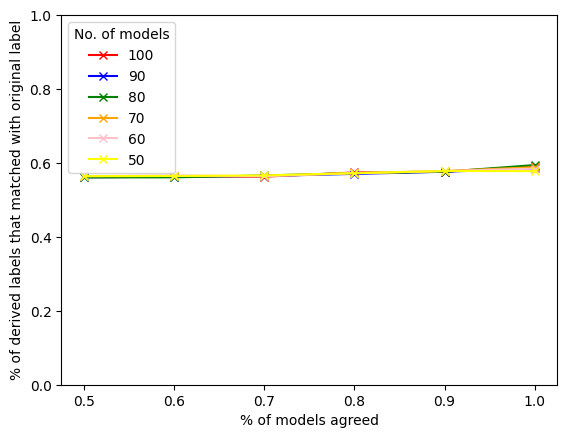

In [561]:
fig = plt.figure()
# x = 
plt.plot(derived_label_match_results[100].keys(), derived_label_match_results[100].values(), marker='x', color='red', label='100')
# plt.scatter(bkd_exp_results[100].keys(), derived_label_match_results[100].values(), s=list(bkd_exp_results[100].values()), color='red', alpha=0.6)

plt.plot(derived_label_match_results[90].keys(), derived_label_match_results[90].values(), marker='x', color='blue', label='90')
# plt.scatter(bkd_exp_results[90].keys(), derived_label_match_results[90].values(), s=list(bkd_exp_results[90].values()), color='blue', alpha=0.6)

plt.plot(derived_label_match_results[80].keys(), derived_label_match_results[80].values(), marker='x', color='green', label='80')
# plt.scatter(bkd_exp_results[80].keys(), derived_label_match_results[80].values(), s=list(bkd_exp_results[80].values()), color='green', alpha=0.6)

plt.plot(derived_label_match_results[70].keys(), derived_label_match_results[70].values(), marker='x', color='orange', label='70')
# plt.scatter(bkd_exp_results[70].keys(), derived_label_match_results[70].values(), s=list(bkd_exp_results[70].values()), color='orange', alpha=0.6)

plt.plot(derived_label_match_results[60].keys(), derived_label_match_results[60].values(), marker='x', color='pink', label='60')
# plt.scatter(bkd_exp_results[60].keys(), derived_label_match_results[60].values(), s=list(bkd_exp_results[60].values()), color='pink', alpha=0.6)

plt.plot(derived_label_match_results[50].keys(), derived_label_match_results[50].values(), marker='x', color='yellow', label='50')
# plt.scatter(bkd_exp_results[50].keys(), derived_label_match_results[50].values(), s=list(bkd_exp_results[50].values()), color='yellow', alpha=0.6)

plt.xticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
plt.xlabel("% of models agreed")

plt.ylim(0, 1)
plt.ylabel("% of derived labels that matched with original label")
plt.legend(title='No. of models')
# plt.title("{}".format(model_name+": Labels Match for "+derived_dataset))

plt.savefig(dataset_combo+"_"+model_name+'_perc_Labels_Match_Forward_Expr.png', dpi=600)

In [562]:
# max_val = 0
# min_val = 999999
# for key in fwd_exp_results.keys():
#     # val = 
#     if max_val < max(fwd_exp_results[key].values()):
#         max_val = max(fwd_exp_results[key].values())
    
#     if min_val > min(fwd_exp_results[key].values()):
#         min_val = min(fwd_exp_results[key].values())

#     # print(max(fwd_exp_results[key].values()))

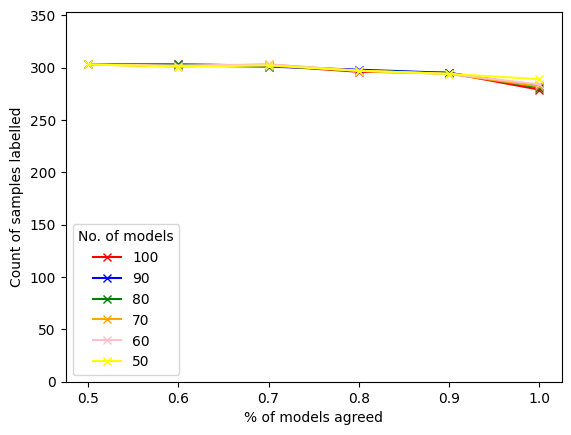

In [563]:
fig = plt.figure()
# x = 
plt.plot(fwd_exp_results[100].keys(), fwd_exp_results[100].values(), marker='x', color='red', label='100')
# plt.scatter(bkd_exp_results[100].keys(), derived_label_match_results[100].values(), s=list(bkd_exp_results[100].values()), color='red', alpha=0.6)

plt.plot(fwd_exp_results[90].keys(), fwd_exp_results[90].values(), marker='x', color='blue', label='90')
# plt.scatter(bkd_exp_results[90].keys(), derived_label_match_results[90].values(), s=list(bkd_exp_results[90].values()), color='blue', alpha=0.6)

plt.plot(fwd_exp_results[80].keys(), fwd_exp_results[80].values(), marker='x', color='green', label='80')
# plt.scatter(bkd_exp_results[80].keys(), derived_label_match_results[80].values(), s=list(bkd_exp_results[80].values()), color='green', alpha=0.6)

plt.plot(fwd_exp_results[70].keys(), fwd_exp_results[70].values(), marker='x', color='orange', label='70')
# plt.scatter(bkd_exp_results[70].keys(), derived_label_match_results[70].values(), s=list(bkd_exp_results[70].values()), color='orange', alpha=0.6)

plt.plot(fwd_exp_results[60].keys(), fwd_exp_results[60].values(), marker='x', color='pink', label='60')
# plt.scatter(bkd_exp_results[60].keys(), derived_label_match_results[60].values(), s=list(bkd_exp_results[60].values()), color='pink', alpha=0.6)

plt.plot(fwd_exp_results[50].keys(), fwd_exp_results[50].values(), marker='x', color='yellow', label='50')
# plt.scatter(bkd_exp_results[50].keys(), derived_label_match_results[50].values(), s=list(bkd_exp_results[50].values()), color='yellow', alpha=0.6)

plt.xticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
plt.xlabel("% of models agreed")

plt.ylim(0, len_derived+50)
plt.ylabel("Count of samples labelled")
plt.legend(title='No. of models')
# plt.title("{}".format(model_name+": ("+derived_dataset+') Samples Labelled Out of '+str(derived_dataset_count)))

fname = dataset_combo+"_"+model_name+"_"+derived_dataset+'_Forward_Expr_Samples_Labelled.png'

plt.savefig(fname, dpi=600)

In [564]:
count_correctly_labelled

{100: {0.5: 171, 0.6: 171, 0.7: 170, 0.8: 170, 0.9: 170, 1.0: 165},
 90: {0.5: 170, 0.6: 170, 0.7: 170, 0.8: 170, 0.9: 170, 1.0: 165},
 80: {0.5: 170, 0.6: 170, 0.7: 171, 0.8: 170, 0.9: 170, 1.0: 167},
 70: {0.5: 171, 0.6: 170, 0.7: 171, 0.8: 170, 0.9: 170, 1.0: 166},
 60: {0.5: 171, 0.6: 171, 0.7: 171, 0.8: 170, 0.9: 170, 1.0: 166},
 50: {0.5: 171, 0.6: 170, 0.7: 171, 0.8: 170, 0.9: 170, 1.0: 167}}

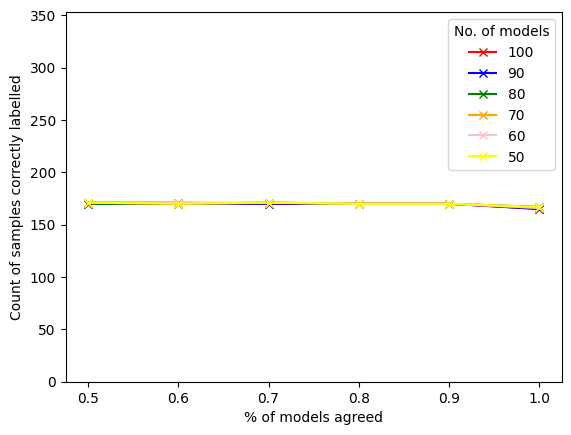

In [565]:
# count_correctly_labelled


fig = plt.figure()
# x = 
plt.plot(count_correctly_labelled[100].keys(), count_correctly_labelled[100].values(), marker='x', color='red', label='100')
# plt.scatter(bkd_exp_results[100].keys(), derived_label_match_results[100].values(), s=list(bkd_exp_results[100].values()), color='red', alpha=0.6)

plt.plot(count_correctly_labelled[90].keys(), count_correctly_labelled[90].values(), marker='x', color='blue', label='90')
# plt.scatter(bkd_exp_results[90].keys(), derived_label_match_results[90].values(), s=list(bkd_exp_results[90].values()), color='blue', alpha=0.6)

plt.plot(count_correctly_labelled[80].keys(), count_correctly_labelled[80].values(), marker='x', color='green', label='80')
# plt.scatter(bkd_exp_results[80].keys(), derived_label_match_results[80].values(), s=list(bkd_exp_results[80].values()), color='green', alpha=0.6)

plt.plot(count_correctly_labelled[70].keys(), count_correctly_labelled[70].values(), marker='x', color='orange', label='70')
# plt.scatter(bkd_exp_results[70].keys(), derived_label_match_results[70].values(), s=list(bkd_exp_results[70].values()), color='orange', alpha=0.6)

plt.plot(count_correctly_labelled[60].keys(), count_correctly_labelled[60].values(), marker='x', color='pink', label='60')
# plt.scatter(bkd_exp_results[60].keys(), derived_label_match_results[60].values(), s=list(bkd_exp_results[60].values()), color='pink', alpha=0.6)

plt.plot(count_correctly_labelled[50].keys(), count_correctly_labelled[50].values(), marker='x', color='yellow', label='50')
# plt.scatter(bkd_exp_results[50].keys(), derived_label_match_results[50].values(), s=list(bkd_exp_results[50].values()), color='yellow', alpha=0.6)

plt.xticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
plt.xlabel("% of models agreed")

plt.ylim([0, len_derived+50])
plt.ylabel("Count of samples correctly labelled")
plt.legend(title='No. of models')
# plt.title("{}".format(model_name+": ("+derived_dataset+') Samples Correctly Labelled'))

plt.savefig(dataset_combo+"_"+model_name+"_"+derived_dataset+'_Forward_Expr_Samples_Correctly_Labelled.png', dpi=600)

In [566]:
model_name, bkd_exp_results

('LR',
 {100: {0.5: 294, 0.6: 294, 0.7: 294, 0.8: 293, 0.9: 293, 1.0: 290},
  90: {0.5: 294, 0.6: 294, 0.7: 294, 0.8: 294, 0.9: 293, 1.0: 288},
  80: {0.5: 294, 0.6: 294, 0.7: 294, 0.8: 293, 0.9: 293, 1.0: 288},
  70: {0.5: 294, 0.6: 294, 0.7: 293, 0.8: 294, 0.9: 292, 1.0: 289},
  60: {0.5: 294, 0.6: 294, 0.7: 293, 0.8: 294, 0.9: 292, 1.0: 289},
  50: {0.5: 294, 0.6: 294, 0.7: 294, 0.8: 293, 0.9: 292, 1.0: 289}})

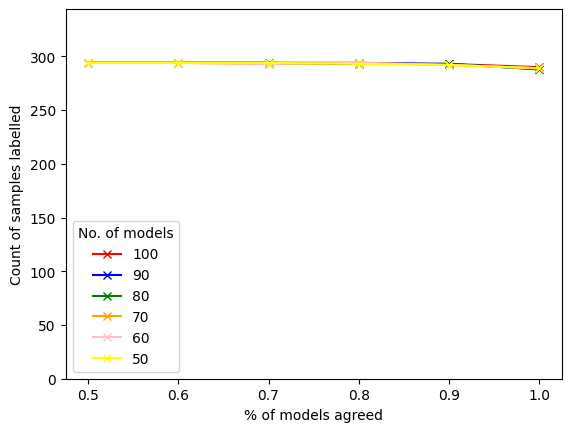

In [567]:
fig = plt.figure()
# x = 
plt.plot(bkd_exp_results[100].keys(), bkd_exp_results[100].values(), marker='x', color='red', label='100')
# plt.scatter(bkd_exp_results[100].keys(), derived_label_match_results[100].values(), s=list(bkd_exp_results[100].values()), color='red', alpha=0.6)

plt.plot(bkd_exp_results[90].keys(), bkd_exp_results[90].values(), marker='x', color='blue', label='90')
# plt.scatter(bkd_exp_results[90].keys(), derived_label_match_results[90].values(), s=list(bkd_exp_results[90].values()), color='blue', alpha=0.6)

plt.plot(bkd_exp_results[80].keys(), bkd_exp_results[80].values(), marker='x', color='green', label='80')
# plt.scatter(bkd_exp_results[80].keys(), derived_label_match_results[80].values(), s=list(bkd_exp_results[80].values()), color='green', alpha=0.6)

plt.plot(bkd_exp_results[70].keys(), bkd_exp_results[70].values(), marker='x', color='orange', label='70')
# plt.scatter(bkd_exp_results[70].keys(), derived_label_match_results[70].values(), s=list(bkd_exp_results[70].values()), color='orange', alpha=0.6)

plt.plot(bkd_exp_results[60].keys(), bkd_exp_results[60].values(), marker='x', color='pink', label='60')
# plt.scatter(bkd_exp_results[60].keys(), derived_label_match_results[60].values(), s=list(bkd_exp_results[60].values()), color='pink', alpha=0.6)

plt.plot(bkd_exp_results[50].keys(), bkd_exp_results[50].values(), marker='x', color='yellow', label='50')
# plt.scatter(bkd_exp_results[50].keys(), derived_label_match_results[50].values(), s=list(bkd_exp_results[50].values()), color='yellow', alpha=0.6)

plt.xticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
plt.xlabel("% of models agreed")

plt.ylim(0, len_base+50)
plt.ylabel("Count of samples labelled")
plt.legend(title='No. of models')
# plt.title("{}".format(model_name+": ("+base_dataset+') Samples Labelled Out of '+str(base_dataset_count)))

plt.savefig(dataset_combo+"_"+model_name+"_"+base_dataset+'_Reverse_Expr_Samples_Labelled.png', dpi=600)